In [ ]:
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import matplotlib.colors as mcolors
from PIL import Image
import os
from pathlib import Path

# ============================================================================
# Configuration
# ============================================================================
BASE_DIR = Path("/Users/chrispham/Documents/Data Science/Skin Cancer/Skin Cancer Detection/ISIC-2019")
ANNOTATION_DIR = BASE_DIR / "Annotations"
IMAGE_DIR = BASE_DIR / "ISIC Images"  # Adjust if images are elsewhere

# Color mapping for each label type (using colors from the XML or custom)
LABEL_COLORS = {
    "Rule 1.1 - Structure (Chaotic - Network)": "#33ddff",
    "Rule 1.1 - Structure (Non Chaotic)": "#b3c459",
    "Rule 1.2 - Colour (Chaotic)": "#fa3253",
    "Rule 1.2 - Colour (Non Chaotic)": "#b96467",
    "Rule 2.1: Clue 1 – Eccentric Structureless Area": "#ff007c",
    "Rule 2.2: Clue 2 – Thick Lines (Reticular or Branched)": "#ddff33",
    "Rule 2.3: Clue 3 – Grey/Blue Structures": "#34d1b7",
    "Rule 2.4: Clue 4 – Black Dots/Clods, Peripheral": "#ff6037",
    "Rule 2.5: Clue 5 – Lines Radial or Pseudopods, Segmental": "#24b353",
    "Rule 2.6: Clue 6 – White Lines": "#b83df5",
    "Rule 2.7: Clue 7 – Polymorphous Vessels": "#ffcc33",
    "Rule 2.8: Clue 8 – Parallel/Ridge Lines or Chaotic Nail Lines": "#32b7fa",
    "Rule 2.9: Clue 9 - Angulated Lines": "#86ffe8",
    "Hair": "#33ddff",
    "No Clues": "#5d626b",
}


def parse_annotation_file(xml_path):
    """
    Parse CVAT XML annotation file and extract image annotations.
    
    Returns:
        dict: {image_name: [(label, points), ...], ...}
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    annotations = {}
    
    for image_elem in root.findall('.//image'):
        image_name = image_elem.get('name')
        width = int(image_elem.get('width'))
        height = int(image_elem.get('height'))
        
        image_annotations = []
        
        # Parse polylines
        for polyline in image_elem.findall('polyline'):
            label = polyline.get('label')
            points_str = polyline.get('points')
            
            # Parse points: "x1,y1;x2,y2;..." -> [(x1,y1), (x2,y2), ...]
            points = []
            for point_pair in points_str.split(';'):
                x, y = map(float, point_pair.split(','))
                points.append((x, y))
            
            image_annotations.append({
                'label': label,
                'points': np.array(points),
                'type': 'polyline'
            })
        
        # Parse polygons (if any)
        for polygon in image_elem.findall('polygon'):
            label = polygon.get('label')
            points_str = polygon.get('points')
            
            points = []
            for point_pair in points_str.split(';'):
                x, y = map(float, point_pair.split(','))
                points.append((x, y))
            
            image_annotations.append({
                'label': label,
                'points': np.array(points),
                'type': 'polygon'
            })
        
        annotations[image_name] = {
            'width': width,
            'height': height,
            'annotations': image_annotations
        }
    
    return annotations



In [ ]:
def visualize_by_image_name_multiple_masks(image_name, annotation_dir=ANNOTATION_DIR, 
                                            image_dir=IMAGE_DIR, cols=3, alpha=0.5,
                                            exclude_labels=["Hair"]):
    """
    Find an image by name across all annotation files and visualize each mask separately.
    
    Args:
        image_name: Name of the image (e.g., "ISIC_0013490_downsampled.jpg")
        annotation_dir: Directory containing XML annotation files
        image_dir: Directory containing images
        cols: Number of columns in the grid
        alpha: Transparency for mask fill
        exclude_labels: List of labels to exclude from visualization
    """
    annotation_files = list(annotation_dir.glob("*.xml"))
    
    # Search for the image in all annotation files
    for xml_file in annotation_files:
        annotations = parse_annotation_file(xml_file)
        
        if image_name in annotations:
            print(f"Found in: {xml_file.name}")
            image_data = annotations[image_name]
            
            # Filter out excluded labels
            filtered_annotations = [
                ann for ann in image_data['annotations'] 
                if ann['label'] not in exclude_labels
            ]
            
            # Find image file
            image_path = image_dir / image_name
            if not image_path.exists():
                image_path = image_dir / image_name.replace('_downsampled', '')
            
            if not image_path.exists():
                print(f"Error: Image file not found: {image_path}")
                return None, None
            
            # Load image
            img = Image.open(image_path)
            img_array = np.array(img)
            
            n_annotations = len(filtered_annotations)
            
            if n_annotations == 0:
                print(f"No annotations for {image_name} (after filtering)")
                fig, ax = plt.subplots(figsize=(12, 8))
                ax.imshow(img_array)
                ax.set_title(f"No annotations: {image_name}", fontsize=12)
                ax.axis('off')
                plt.show()
                return fig, ax
            
            # Calculate grid size (add 1 for the combined view)
            total_plots = n_annotations + 1
            rows = (total_plots + cols - 1) // cols
            fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
            axes = np.array(axes).flatten()
            
            # First subplot: All masks combined
            ax = axes[0]
            ax.imshow(img_array)
            for ann in filtered_annotations:
                label = ann['label']
                points = ann['points']
                color = LABEL_COLORS.get(label, '#ffffff')
                polygon = Polygon(points, closed=True,
                                 facecolor=mcolors.to_rgba(color, alpha=alpha),
                                 edgecolor=color, linewidth=2)
                ax.add_patch(polygon)
            ax.set_title("All Masks Combined", fontsize=11, fontweight='bold', color='green')
            ax.axis('off')
            
            # Remaining subplots: Individual masks
            for idx, ann in enumerate(filtered_annotations):
                ax = axes[idx + 1]
                ax.imshow(img_array)
                
                label = ann['label']
                points = ann['points']
                color = LABEL_COLORS.get(label, '#ffffff')
                
                polygon = Polygon(points, closed=True,
                                 facecolor=mcolors.to_rgba(color, alpha=alpha),
                                 edgecolor=color, linewidth=3)
                ax.add_patch(polygon)
                
                short_label = label if len(label) <= 45 else label[:42] + "..."
                ax.set_title(short_label, fontsize=9, fontweight='bold')
                ax.axis('off')
            
            # Hide empty subplots
            for idx in range(n_annotations + 1, len(axes)):
                axes[idx].axis('off')
            
            fig.suptitle(f"{image_name}\n({n_annotations} annotations)", 
                        fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
            
            print(f"\nAnnotations ({n_annotations}):")
            for i, ann in enumerate(filtered_annotations, 1):
                print(f"  {i}. {ann['label']}")
            
            return fig, axes
    
    print(f"Image '{image_name}' not found in any annotation file.")
    return None, None

Found in: Training 1.xml


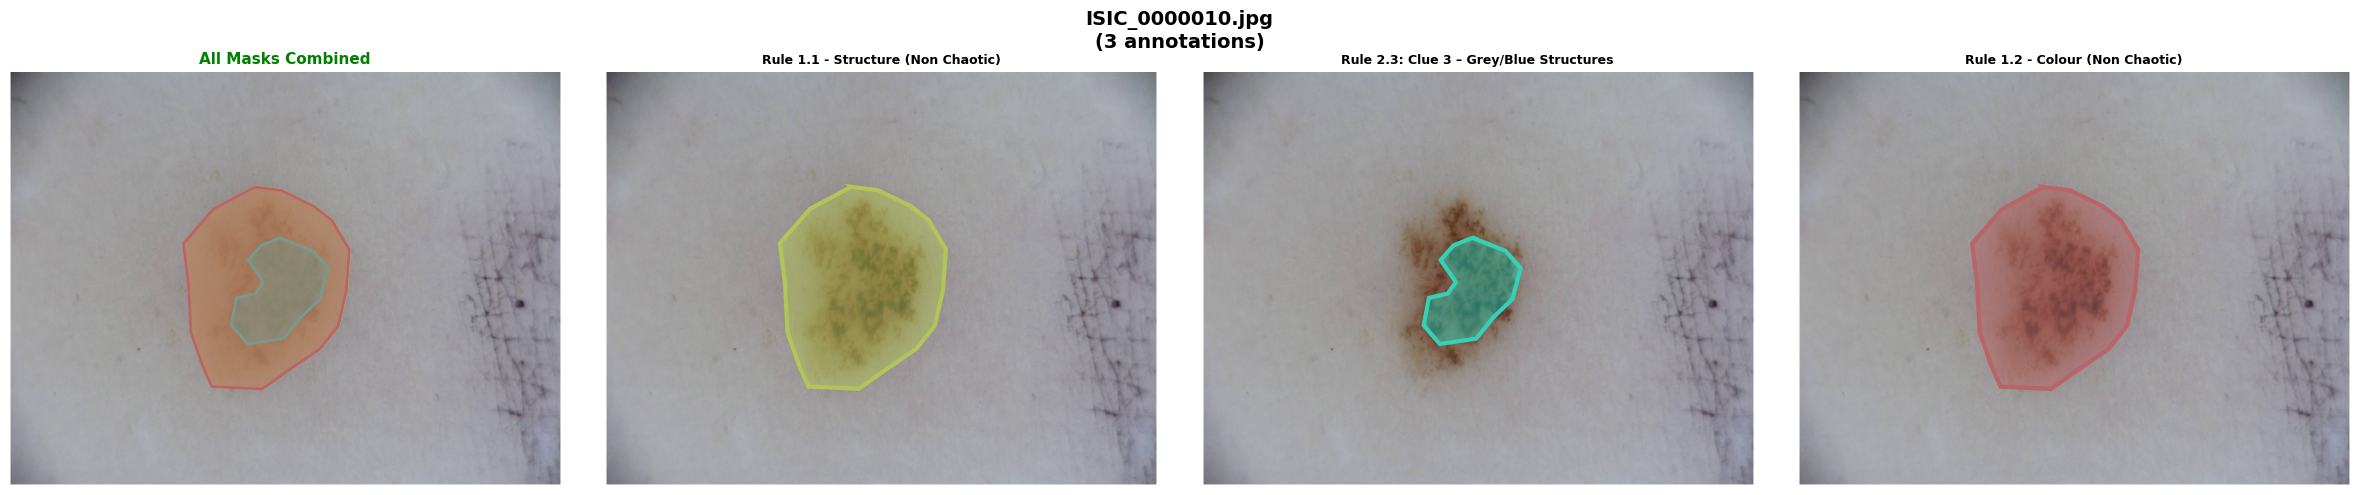


Annotations (3):
  1. Rule 1.1 - Structure (Non Chaotic)
  2. Rule 2.3: Clue 3 – Grey/Blue Structures
  3. Rule 1.2 - Colour (Non Chaotic)


(<Figure size 2400x500 with 4 Axes>,
 array([<Axes: title={'center': 'All Masks Combined'}>,
        <Axes: title={'center': 'Rule 1.1 - Structure (Non Chaotic)'}>,
        <Axes: title={'center': 'Rule 2.3: Clue 3 – Grey/Blue Structures'}>,
        <Axes: title={'center': 'Rule 1.2 - Colour (Non Chaotic)'}>],
       dtype=object))

In [ ]:
# Search for image without _downsampled suffix (it will try both)
visualize_by_image_name_multiple_masks("ISIC_0000010.jpg", cols=4)

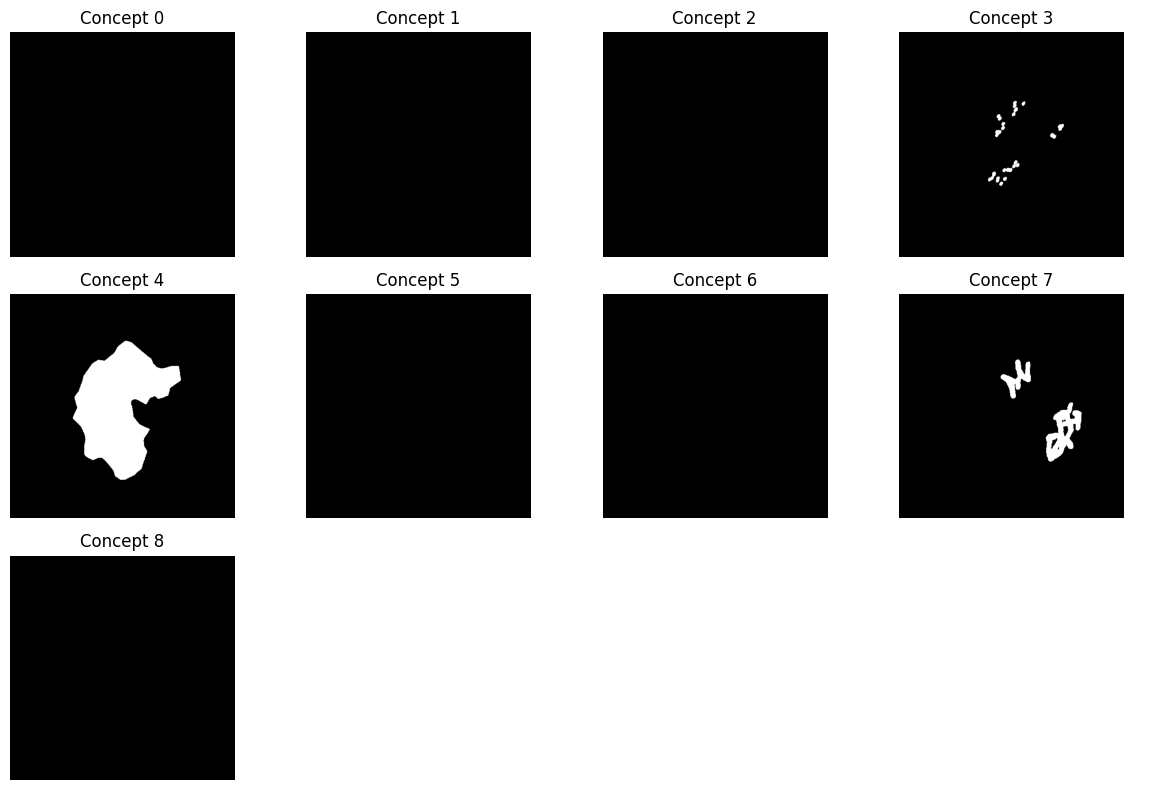

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mask = np.load("../chaos_and_clues/GroundTruthMasks/whitecircle_task_additional_dataset_2025_08_19_06_41_15_cvat_f_acral melanoma radial lines_aug2_mask.npy")

fig, axes = plt.subplots(3, 4, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    if i < mask.shape[0]:
        ax.imshow(mask[i], cmap="gray")
        ax.set_title(f"Concept {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()